[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fw-ai/cookbook/blob/main/training/case-studies/sft_bfcl_toolcalls/bfcl_toolcall_sft.ipynb)

# SFT on the Training API: the loop you own

Supervised fine-tuning through the
**[Training API](https://docs.fireworks.ai/fine-tuning/training-api/introduction)** — where you
write the training loop instead of handing Fireworks a job spec.

**Muse Glimmer 30B**, trained on the **serverless** trainer pool: no provisioning, per-token
billing, attach in seconds. §5 evaluates the base model, §6 trains, §7 runs the three raw API calls
that `sft_loop` is built from, and §8 scores the result. §9 shows what the *same* `Config` looks
like on dedicated and as a managed job, so you can see exactly what changes between the three.

Scored on **BFCL V4** non-live: 1,390 rows, the board's own AST checker, both headline metrics
(tool-call accuracy *and* abstention) reported every time — each is trivially gameable alone.

> Training and deployment cells cost money, though far less here than on dedicated: serverless
> training is billed per token with no idle GPU, and the base-model eval needs no deployment at all.
> **Measure your own base before designing the training mix.** Whether abstention data helps or
> hurts depends on where your model already sits; one baseline sweep is the only way to know.

## 1. Setup & credentials

```bash
git clone https://github.com/fw-ai/cookbook && cd cookbook/training
uv venv --python 3.12 && source .venv/bin/activate   # 3.14 breaks eval-protocol's anyio usage
uv pip install -e .
uv pip install "bfcl-eval==2025.12.17" datasets openai matplotlib python-dotenv soundfile
```

`.env` needs `FIREWORKS_API_KEY`, `FIREWORKS_ACCOUNT_ID`, `HF_TOKEN` (xLAM is gated). Optional:
`WANDB_API_KEY` / `WANDB_ENTITY`. The training SDK and `tinker` come from
`fireworks-ai[training]`, which `-e .` pulls in; `soundfile` is an undeclared dependency of
`bfcl-eval`'s checker.

In [1]:
import json
import os
import sys
import time
import uuid
from pathlib import Path

import dotenv
from fireworks import Fireworks

dotenv.load_dotenv(dotenv.find_dotenv(usecwd=True), override=True)

# This notebook imports its sibling modules (bfcl_data, bfcl_score, build_bfcl_sft)
# and the cookbook's `training` package. Locate both whether the kernel started in
# this folder or at the repo root.
HERE = next(
    (p for p in [Path.cwd(), *Path.cwd().parents, Path.cwd() / "training/case-studies/sft_bfcl_toolcalls"]
     if (p / "bfcl_data.py").exists()),
    None,
)
assert HERE is not None, "launch from training/case-studies/sft_bfcl_toolcalls/ (or the repo root)"
REPO_ROOT = next((p for p in [HERE, *HERE.parents] if (p / "training" / "recipes" / "sft_loop.py").exists()), None)
assert REPO_ROOT is not None, "could not find the cookbook repo root"
for _p in (str(HERE), str(REPO_ROOT)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

# noqa below: sibling module, so this import must follow the sys.path setup above.
from bfcl_score import reasoning_control_for, thinking_enabled_for  # noqa: E402

assert os.getenv("FIREWORKS_API_KEY"), "FIREWORKS_API_KEY missing"
# Serverless training needs an ACCOUNT-SCOPED key. A multi-account key fails later
# with `create_session: account not found`, which does not name the real cause.
ACCOUNT_ID = os.getenv("FIREWORKS_ACCOUNT_ID", "").replace("accounts/", "", 1)
assert ACCOUNT_ID, "FIREWORKS_ACCOUNT_ID missing (put it in .env; it is not set by firectl login)"

# The gated xLAM repo needs a token: accept the terms once at
# https://huggingface.co/datasets/Salesforce/xlam-function-calling-60k then `huggingface-cli login`.
HF_TOKEN = os.getenv("HF_TOKEN") or os.getenv("HUGGING_FACE_HUB_TOKEN")

client = Fireworks()
print("account:", ACCOUNT_ID, "| HF token:", "yes" if HF_TOKEN else "no (xLAM will fail)")

account: my-account | HF token: yes


## 2. Which of the three are you using?

The [Training Overview](https://docs.fireworks.ai/fine-tuning/finetuning-intro) routes you with
three questions: *does a standard job do it?* → **Managed**. *Need full-parameter or a custom loss?*
→ **Dedicated**. *Is your base model in the serverless pool?* → **Serverless**, else **Dedicated**.

| | [Managed](https://docs.fireworks.ai/fine-tuning/managed-finetuning-intro) | [Serverless](https://docs.fireworks.ai/fine-tuning/training-api/serverless) | [Dedicated](https://docs.fireworks.ai/fine-tuning/training-api/dedicated) |
| --- | --- | --- | --- |
| You write | a dataset + hyperparameters (epochs, LoRA rank, LR) | dataset, hyperparameters, **and the training loop**: batching, loss, optimizer steps, checkpointing | the same loop, **plus the hardware choice** (training shape) and trainer lifecycle |
| Tuning mode | LoRA (see note) | LoRA only | LoRA **or** full-parameter |
| Billing | per job | per token | GPU-hours, for as long as the trainer is up |
| Provisioning | none | none (attach to a pool) | a trainer job, ~10 min |
| Custom loss / reward | no | yes | yes |

Managed is one call with no loop — not run here; `sft_prompt_router` and `sft_cord_receipts` are the
runnable managed examples:

```python
job = client.supervised_fine_tuning_jobs.create(
    dataset=dataset_name,          # the one required argument
    base_model=BASE_MODEL, output_model=f"accounts/{ACCOUNT_ID}/models/{OUTPUT_MODEL_ID}",
    epochs=1, lora_rank=16, learning_rate=2e-5,
    batch_size_samples=32,         # the managed equivalent of sft_loop's batch_size
    eval_auto_carveout=True,       # hold out 10% and report eval loss per epoch
)
```

**This notebook takes the serverless Training API fork** — §6 trains, §7 shows the
primitives underneath, and §9 puts the dedicated and managed equivalents of that same
run side by side as config, so the differences are concrete rather than abstract.

> **Managed tuning mode.** The
> [managed docs](https://docs.fireworks.ai/fine-tuning/managed-finetuning-intro#tuning-modes-and-context-length)
> describe managed training as LoRA only and point you at the Training API for full-parameter. The
> managed job API does accept `lora_rank=0` as a full-parameter request, but it is admitted only
> when the base model is flagged full-parameter-tunable — and that flag is not published on the
> model resource, so you cannot check it yourself. Treat full-parameter as a Training API feature
> (§6) unless Fireworks has told you otherwise for your model.

> **The three paths do not cover the same models.** Muse Glimmer has a serverless pool and two
> dedicated shapes but is **not** enabled for Managed SFT (`managedSft: false`). Check the
> [Models catalog](https://docs.fireworks.ai/fine-tuning/models) per model *and* per method.

## 3. Configuration

**`BASE_MODEL` must be in the serverless trainer pool** for §6, and no field on the model resource
tells you. Check the [Models catalog](https://docs.fireworks.ai/fine-tuning/models); §7 probes it
from code.

**`REASONING_EFFORT` keeps the model from spending its output budget reasoning instead of calling
a tool.** A reasoning model can run past `max_tokens`, and a truncated reply carries no parseable
call — which scores as a *deliberate abstention* rather than as the failure it is.
`assert_thinking_parity()` checks the setting is coherent with the renderer, and §5's smoke gate
checks it actually took effect. The README has the measurements behind the default.

In [2]:
# CONFIG
BASE_MODEL = "accounts/fireworks/models/muse-glimmer-30b"   # must be in the SERVERLESS TRAINER
TOKENIZER = "meta-models/Muse-Glimmer-30B"                  # pool -- section 7 probes this
RENDERER = "muse_glimmer"

# Required on serverless: the pool has no training shape to resolve a sequence length from, so
# this is YOUR choice. The pool allows far more (131k for this model); 32k is simply more than
# our longest xLAM row.
MAX_SEQ_LEN = 32_768

# SFT knobs. lora_rank must be > 0: the serverless pool is LoRA-only regardless of model.
LORA_RANK, LORA_ALPHA = 16, 32
# 1 epoch at 2e-5, not 3 at 1e-4. The job is to add tool-calling skill without overwriting what
# the base already does well; a long, hot run costs more than it buys.
EPOCHS, BATCH_SIZE, LEARNING_RATE = 1, 32, 2e-5

# Training set size. The negative share moves BOTH headline metrics, in OPPOSITE directions --
# too few and the model learns to always call (irrelevance falls), too many and it refuses valid
# calls (AST falls). 1,800/13,800 = 13%, close to the 17% the eval slice itself carries.
# The README has this dial measured before you change it.
N_POSITIVE, N_NEGATIVE = 12_000, 1_800

# -- Eval ------------------------------------------------------------------------------
# Reasoning control, required for this renderer family. Keep it low: a reply that runs past
# MAX_TOKENS is truncated, and a truncated reply scores as a deliberate abstention. Verify the
# effect on the smoke gate rather than assuming it -- see the README.
REASONING_EFFORT = "low"
MAX_TOKENS = 1024            # headroom above the ~70 tokens a low-effort tool call needs

SMOKE_CATEGORIES = ["simple_python"]     # the risk gate in section 5
SMOKE_ROWS = 200
# Section 8's canary: the two categories that decide whether a data change worked, read before
# paying for the other five. `irrelevance` is where negatives help; `multiple` is the AST
# category most sensitive to the call prior, so it is where they hurt first.
PROBE_CATEGORIES = ["irrelevance", "multiple"]
CONCURRENCY = 12
ACCELERATOR_TYPE = "NVIDIA_H200_141GB"   # the SDK requires an explicit accelerator; firectl does not

# Derived, never hand-set. Two independent knobs drift apart silently; a derived one cannot.
ENABLE_THINKING = thinking_enabled_for(RENDERER)

RUN = uuid.uuid4().hex[:6]
OUTPUT_MODEL_ID = f"glimmer-bfcl-{RUN}"
DEPLOYMENT_ID = f"glm-{RUN}"
TRAIN_FILE = "./bfcl_sft_train.jsonl"
BFCL_PROJECT_ROOT = "./bfcl_run"
BASE_LABEL = f"{OUTPUT_MODEL_ID}-base"

# Reuse a previous run's BASE scores instead of re-scoring 1,390 rows. The base model does not
# change while you iterate on training data, so neither do its scores. Must have been produced
# with the SAME renderer and reasoning settings, or it is not comparable.
REUSE_BASE_LABEL = None
if REUSE_BASE_LABEL:
    BASE_LABEL = REUSE_BASE_LABEL

print("run:", RUN, "| base:", BASE_MODEL.split("/")[-1], "| renderer:", RENDERER)
print("reasoning control:", reasoning_control_for(RENDERER), "->", REASONING_EFFORT)

run: e189ce | base: muse-glimmer-30b | renderer: muse_glimmer
reasoning control: reasoning_effort -> low


## 4. The benchmark, and the training set

**BFCL V4 non-live**: 1,390 rows, stateless, single-turn, AST-scored. We skip `multi_turn` (needs a
stateful sandbox), `agentic` (needs a paid SerpAPI key), and `format_sensitivity` (non-scoring).

Two scoring properties shape everything downstream:

- **AST is strict and binary per row** — name, every `required` param, no hallucinated params,
  types, and allowed values must all check out.
- **Irrelevance is scored structurally**: correct iff the model emits *no* parseable call, arguments
  never inspected. So a model scores 100% by refusing everything — and a *truncated* reply scores
  as a correct abstention.

**Training data:** [xlam-function-calling-60k](https://huggingface.co/datasets/Salesforce/xlam-function-calling-60k)
positives + [xlam-irrelevance-7.5k](https://huggingface.co/datasets/MadeAgents/xlam-irrelevance-7.5k)
negatives (a negative is a row whose `answers` is `[]`). BFCL ships **no train split** and never
decontaminated the non-live categories, so `build_bfcl_sft.py` filters against the eval queries and
prints what it dropped. Everything downstream needs only `{"messages": [...], "tools": [...]}` —
point it at your own data and nothing else changes.

In [3]:
from bfcl_data import NON_LIVE, NON_LIVE_AST, load_answers, load_non_live, to_openai_tools, user_prompt

EVAL = load_non_live(cache_dir=f"{BFCL_PROJECT_ROOT}/data")      # row counts asserted on load
ANSWERS = {cat: load_answers(cat, cache_dir=f"{BFCL_PROJECT_ROOT}/data") for cat in NON_LIVE}

for cat, rows in EVAL.items():
    print(f"{cat:22s} {len(rows):>5d}")
print(f"{'TOTAL':22s} {sum(len(r) for r in EVAL.values()):>5d}")

row = EVAL["parallel"][0]
print("\n--- a `parallel` row: one prompt, two expected calls ---")
print("prompt :", user_prompt(row))
print("tools  :", json.dumps(to_openai_tools(row["function"])[0])[:150], "...")
print("truth  :", json.dumps(ANSWERS["parallel"][row["id"]]))

simple_python            400
simple_java              100
simple_javascript         50
multiple                 200
parallel                 200
parallel_multiple        200
irrelevance              240
TOTAL                   1390

--- a `parallel` row: one prompt, two expected calls ---
prompt : Play songs from the artists Taylor Swift and Maroon 5, with a play time of 20 minutes and 15 minutes respectively, on Spotify.
tools  : {"type": "function", "function": {"name": "spotify_play", "description": "Play specific tracks from a given artist for a specific time duration.", "pa ...
truth  : [{"spotify.play": {"artist": ["Taylor Swift"], "duration": [20]}}, {"spotify.play": {"artist": ["Maroon 5"], "duration": [15]}}]


In [4]:
from build_bfcl_sft import build, tool_name_overlap, write_jsonl
from bfcl_data import eval_tool_names, load_eval_queries

rows, stats = build(
    load_eval_queries(cache_dir=f"{BFCL_PROJECT_ROOT}/data"),
    n_positive=N_POSITIVE,
    n_negative=N_NEGATIVE,
    hf_token=HF_TOKEN,
)
write_jsonl(rows, TRAIN_FILE)

shared, total = tool_name_overlap(rows, eval_tool_names(cache_dir=f"{BFCL_PROJECT_ROOT}/data"))
print(json.dumps(stats, indent=2))
print(f"\nleakage dropped     : {stats.get('dropped_leaked', 0)} rows")
print(f"tool-name overlap   : {shared}/{total} training function names also appear in BFCL non-live")
print(f"wrote {len(rows)} rows -> {TRAIN_FILE}")

{
  "seen": 42699,
  "dropped_leaked": 10,
  "dropped_no_tools": 1289,
  "positives": 12000,
  "negatives": 1800,
  "n_parallel": 6098,
  "n_multi_tool_choice": 9050
}

leakage dropped     : 10 rows
tool-name overlap   : 27/3365 training function names also appear in BFCL non-live
wrote 13800 rows -> ./bfcl_sft_train.jsonl


In [5]:
sample = rows[next(i for i, r in enumerate(rows) if r["messages"][-1].get("tool_calls"))]
print(json.dumps(sample, indent=2)[:1100])
print("\n--- a negative (what teaches abstention) ---")
print(json.dumps(rows[next(i for i, r in enumerate(rows) if not r["messages"][-1].get("tool_calls"))]["messages"], indent=2))

{
  "messages": [
    {
      "role": "user",
      "content": "Add one to the number 42."
    },
    {
      "role": "assistant",
      "content": null,
      "tool_calls": [
        {
          "id": "call_0",
          "type": "function",
          "function": {
            "name": "get_plus_one",
            "arguments": "{\"number\": 42}"
          }
        }
      ]
    }
  ],
  "tools": [
    {
      "type": "function",
      "function": {
        "name": "get_plus_one",
        "description": "This function takes an integer `number` and uses the RapidAPI service to get the number incremented by one.",
        "parameters": {
          "type": "object",
          "properties": {
            "number": {
              "type": "integer",
              "description": "The integer to be incremented."
            }
          },
          "required": []
        }
      }
    }
  ]
}

--- a negative (what teaches abstention) ---
[
  {
    "role": "user",
    "content": "Fetch a specifi

## 5. Evaluate the base model

**Muse Glimmer is on serverless inference, so the baseline is per-token and needs no deployment.**
(The tuned adapter is not — §9.)

The smoke gate runs 200 rows first and checks two things before you pay for 1,390:

- **Did the reasoning setting have the effect it needs to?** It asserts no row hit the token cap.
  A green `assert_thinking_parity()` only proves the *config* is coherent; `finish_reason` proves
  what the server did. Get this wrong and truncated rows score as abstentions, inflating your
  baseline and shrinking the gain you are trying to measure.
- **Is it emitting calls at all?** 0% AST with 100% irrelevance means no calls came out — usually a
  tools-rendering problem, not a weak model. `sample_failures` distinguishes them.

In [6]:
from bfcl_score import (
    assert_thinking_parity,
    generate_category,
    generation_failures,
    load_results,
    score_category,
    summarize,
    truncated_rows,
    write_bfcl_results,
)

# Fail now, not after 1,390 paid requests, if reasoning is controlled by a knob this model
# family ignores. See section 3.
assert_thinking_parity(RENDERER, ENABLE_THINKING, REASONING_EFFORT)


def wait_until(get_fn, ok, bad, label, every=15, tries=200):
    for i in range(tries):
        obj = get_fn()
        state = getattr(obj, "state", None)
        print(f"[{label}] {i + 1:03d} state={state}")
        if state in ok:
            return obj
        if state in bad:
            raise RuntimeError(f"{label} failed: state={state}")
        time.sleep(every)
    raise TimeoutError(f"{label} did not finish")


# Every deployment this notebook creates, so the cleanup cell cannot miss one. Idle on-demand
# GPUs bill by the hour they are up, and a hard-coded teardown list goes stale the moment you
# add a leg.
CREATED_DEPLOYMENTS: list[str] = []


def deploy(model_name, deployment_id):
    """On-demand deployment. Trained LoRAs cannot be served serverless, on any path."""
    CREATED_DEPLOYMENTS.append(deployment_id)
    client.deployments.create(
        base_model=model_name, deployment_id=deployment_id,
        accelerator_type=ACCELERATOR_TYPE, min_replica_count=2, max_replica_count=4,
    )
    wait_until(lambda: client.deployments.get(deployment_id), {"READY"}, {"FAILED"}, "deploy")
    return f"accounts/{ACCOUNT_ID}/deployments/{deployment_id}"


def run_eval(infer_model, label, categories=None, limit=None, reuse=False):
    """Generate + score. Same prompts, same temperature=0.0, on every leg.

    With `reuse=True`, any category that already has a result file under `label` is scored from
    disk instead of regenerated.

    Two guards, for two different ways a sweep can lie to you:

    - A category with generation FAILURES is never scored and never reused. A row that failed to
      generate is written as an empty call list, indistinguishable from a deliberate no-call: it
      scores *wrong* on an AST category and *correct* on irrelevance. Silently averaging that in
      turns an outage into a model result.
    - A category with TRUNCATED rows is reported loudly. Same end state -- no parseable call --
      but the cause is the output budget, not the API, so it needs the opposite fix.
    """
    cats = categories or list(NON_LIVE)
    scores = {}
    for cat in cats:
        subset = EVAL[cat][:limit] if limit else EVAL[cat]
        cached = load_results(BFCL_PROJECT_ROOT, label, cat) if reuse else None
        if cached and generation_failures(cached):
            print(f"  {cat:22s} cached sweep has "
                  f"{generation_failures(cached)} failed rows -- regenerating")
            cached = None
        if cached and len(cached) == len(subset):
            results = cached
            print(f"  {cat:22s} (reused {len(results)} cached rows)")
        else:
            results = generate_category(
                infer_model, subset, concurrency=CONCURRENCY, max_tokens=MAX_TOKENS,
                enable_thinking=ENABLE_THINKING, reasoning_effort=REASONING_EFFORT,
                progress=lambda d, t, c=cat: print(f"  {c}: {d}/{t}"),
            )
            write_bfcl_results(label, cat, results, BFCL_PROJECT_ROOT)
            failed = generation_failures(results)
            if failed:
                raise RuntimeError(
                    f"{cat}: {failed}/{len(subset)} rows never generated. Scoring these would "
                    "report an outage as model behaviour. Results were written, so re-run this "
                    "cell to regenerate only the affected category."
                )
        scores[cat] = score_category(cat, subset, results, ANSWERS[cat])
        trunc = truncated_rows(results)
        flag = f"  <-- {trunc} rows hit the token cap" if trunc else ""
        print(f"  {cat:22s} {scores[cat]['accuracy'] * 100:6.2f}%{flag}")
    return scores

In [7]:
# SMOKE GATE -- 200 rows on serverless inference. No deployment, no GPU held.
if REUSE_BASE_LABEL:
    base_infer = None
    print("reusing cached base eval:", REUSE_BASE_LABEL, "- nothing to gate")
else:
    base_infer = BASE_MODEL          # serverless: the model id IS the inference target
    smoke = run_eval(base_infer, f"{BASE_LABEL}-smoke", SMOKE_CATEGORIES, limit=SMOKE_ROWS)

    # Did the reasoning knob reach the server? `finish_reason` is the only honest answer --
    # a truncated row scores as an abstention, so this cannot be checked from the accuracy.
    smoke_rows = load_results(BFCL_PROJECT_ROOT, f"{BASE_LABEL}-smoke", SMOKE_CATEGORIES[0])
    trunc = truncated_rows(smoke_rows)
    out_tok = [r.get("output_token_count", 0) for r in smoke_rows]
    print(f"\nmean output tokens: {sum(out_tok) / len(out_tok):.0f}  (cap {MAX_TOKENS})")
    assert trunc == 0, (
        f"{trunc}/{len(smoke_rows)} rows hit the {MAX_TOKENS}-token cap, so "
        f"REASONING_EFFORT={REASONING_EFFORT!r} is not having the effect it needs to. Every "
        "truncated row scores as a deliberate abstention -- fix this before paying for 1,390."
    )
    print("no truncation: reasoning control is live")
    print("\nsmoke:", f"{smoke[SMOKE_CATEGORIES[0]]['accuracy'] * 100:.2f}%")
    print("sample failures:",
          json.dumps(smoke[SMOKE_CATEGORIES[0]]["sample_failures"][:2], indent=2)[:700])

  simple_python: 25/200
  simple_python: 50/200
  simple_python: 75/200
  simple_python: 100/200
  simple_python: 125/200
  simple_python: 150/200
  simple_python: 175/200
  simple_python: 200/200
  simple_python           88.50%

mean output tokens: 155  (cap 1024)
no truncation: reasoning control is live

smoke: 88.50%
sample failures: [
  {
    "id": "simple_python_5",
    "detail": {
      "valid": false,
      "error": [
        "Optional parameter 'root_type' not provided and not marked as optional."
      ],
      "error_type": "simple_function_checker:missing_optional"
    }
  },
  {
    "id": "simple_python_13",
    "detail": {
      "valid": false,
      "error": [
        "Nested type checking failed for parameter 'interval'. Expected outer type array with inner type <class 'float'>. Parameter value: [1, 3]."
      ],
      "is_variable": true,
      "error_type": "type_error:nested"
    }
  }
]


In [8]:
# Full baseline over all 1,390 rows -- per-token on serverless, so this costs tokens, not GPU time.
# reuse=True unconditionally: BASE_LABEL embeds the random RUN unless you pointed it at a cache on
# purpose, so nothing stale can be picked up -- and it makes the sweep resumable, which matters
# because run_eval aborts on generation failures.
base_scores = run_eval(base_infer, BASE_LABEL, reuse=True)
base_summary = summarize(base_scores)
print("\nBASE:", json.dumps(base_summary, indent=2))

  simple_python: 25/400
  simple_python: 50/400
  simple_python: 75/400
  simple_python: 100/400
  simple_python: 125/400
  simple_python: 150/400
  simple_python: 175/400
  simple_python: 200/400
  simple_python: 225/400
  simple_python: 250/400
  simple_python: 275/400
  simple_python: 300/400
  simple_python: 325/400
  simple_python: 350/400
  simple_python: 375/400
  simple_python: 400/400
  simple_python           88.50%
  simple_java: 25/100
  simple_java: 50/100
  simple_java: 75/100
  simple_java: 100/100
  simple_java             33.00%
  simple_javascript: 25/50
  simple_javascript: 50/50
  simple_javascript       28.00%
  multiple: 25/200
  multiple: 50/200
  multiple: 75/200
  multiple: 100/200
  multiple: 125/200
  multiple: 150/200
  multiple: 175/200
  multiple: 200/200
  multiple                93.50%
  parallel: 25/200
  parallel: 50/200
  parallel: 75/200
  parallel: 100/200
  parallel: 125/200
  parallel: 150/200
  parallel: 175/200
  parallel: 200/200
  parallel    

## 6. Fine-tune — the Training API on serverless

One `Config`, one `main()`. The
[`sft_loop` recipe](https://docs.fireworks.ai/fine-tuning/training-api/cookbook/sft) renders each
chat row into a `Datum` with per-token loss weights (`0.0` prompt, `1.0` response), submits
`forward_backward(batch, "cross_entropy")`, applies `optim_step`, and promotes the final checkpoint
to a Fireworks model. §7 runs those calls directly.

`serverless=True` attaches to an already-running shared trainer pool rather than provisioning one,
so there is no ~10-minute wait and no idle GPU to pay for. Three preconditions are enforced
client-side before any network call:

- **`lora_rank > 0`** — the pool is LoRA-only (our reading of the published
  [frozen-shared-base design](https://docs.fireworks.ai/fine-tuning/training-api/serverless), not a
  Fireworks statement).
- **`max_seq_len` set explicitly** — there is no training shape to resolve it from.
- **The model must be in the pool** — §7 probes this from code.

**Checkpoints expire differently on this path.** *Sampler* checkpoints are **session-scoped**:
promote anything you want to keep before the session ends, or list and promote start returning
`NOT_FOUND`. *Training* checkpoints are **run-scoped** and outlive the session, so cross-run resume
still works
([docs](https://docs.fireworks.ai/fine-tuning/training-api/serverless#saving-and-loading-checkpoints)).
`sft_loop` promotes for you as long as `output_model_id` is set.

**Consequential defaults it does *not* set:** `eval_auto_carveout=False` (**no in-training eval**),
`dcp_save_interval=0` (no resumable mid-run checkpoints),
`train_on_what="all_assistant_messages"`, `seed=0`. Each is one field away.

In [9]:
import training.recipes.sft_loop as sft_loop
from training.utils import WandBConfig

cfg = sft_loop.Config(
    # -- where the recipe writes logs, metrics, and its dataloader cursor ------------
    log_path=f"./logs_{RUN}",

    # -- what to train ---------------------------------------------------------------
    base_model=BASE_MODEL,
    dataset=TRAIN_FILE,           # JSONL. Only `messages` and `tools` are read off each line --
                                  # every other key is ignored. A row that renders longer than
                                  # max_seq_len is DROPPED, not truncated.
    tokenizer_model=TOKENIZER,    # required: main() raises before any network call if empty
    renderer_name=RENDERER,       # decides the assistant-turn prefix and how `tools` are
                                  # declared -- the train/serve parity knob (section 3).

    # -- LoRA ------------------------------------------------------------------------
    lora_rank=LORA_RANK,          # must be > 0: the serverless pool is LoRA-only, and main()
                                  # raises on lora_rank=0 before any network call.
    lora_alpha=LORA_ALPHA,        # 32 is the SDK default; None delegates to 2 * rank.

    # -- optimisation ----------------------------------------------------------------
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,        # SAMPLES per optimizer step, not tokens:
                                  #     steps = rows * epochs / batch_size
                                  # (`batch_size_samples` is a *managed-job* parameter and is
                                  #  accepted-then-ignored here. Use batch_size.)
    learning_rate=LEARNING_RATE,  # applied per step as a fresh tinker.AdamParams -- there is no
                                  # server-side scheduler; `lr_scheduler` shapes it client-side.
                                  # Adam defaults come from the cookbook's DEFAULT_ADAM
                                  # (weight_decay=0.01, vs 0.0 in the library).

    # -- output ----------------------------------------------------------------------
    output_model_id=OUTPUT_MODEL_ID,   # set it, or the run trains and throws the weights away:
                                       # promotion only fires when this is present.

    # -- infrastructure: the one structural choice in the whole config ---------------
    serverless=True,              # attach to the shared pool. Section 8 shows the alternatives.
    max_seq_len=MAX_SEQ_LEN,      # required here: no training shape to resolve it from.

    # -- observability ---------------------------------------------------------------
    render_samples_file=f"./logs_{RUN}/rendered.jsonl",   # dump what the model actually trains
    render_samples_limit=3,                               # on -- printed in the next cell
    wandb=WandBConfig(
        entity=os.getenv("WANDB_ENTITY"),   # REQUIRED. With no entity, setup_wandb returns False
        project="bfcl-sft",                 # and W&B logging is silently a no-op -- the run still
        run_name=OUTPUT_MODEL_ID,           # trains, you just get no charts.
    ),
)

metrics = sft_loop.main(cfg)
TUNED_MODEL_NAME = f"accounts/{ACCOUNT_ID}/models/{OUTPUT_MODEL_ID}"
print("final metrics:", metrics)
print("tuned model  :", TUNED_MODEL_NAME)

You are using a model of type `muse_glimmer` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
You are using a model of type `muse_glimmer` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
You are using a model of type `muse_glimmer` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not

{"type": "metrics", "step": 1, "ce_loss": 1.07437038592225, "ppl": 2.9281487163788924, "tokens_per_sec": 2601.562308423086, "lr": 2e-05}
{"type": "metrics", "step": 2, "ce_loss": 0.4306824944717917, "ppl": 1.5383070514175685, "tokens_per_sec": 4549.600033370854, "lr": 2e-05}
{"type": "metrics", "step": 3, "ce_loss": 0.9653605952482144, "ppl": 2.6257343131007547, "tokens_per_sec": 5950.751028539622, "lr": 2e-05}
{"type": "metrics", "step": 4, "ce_loss": 0.561553335517569, "ppl": 1.7533939952205924, "tokens_per_sec": 4604.154228812456, "lr": 2e-05}
{"type": "metrics", "step": 5, "ce_loss": 0.5094104801767869, "ppl": 1.6643097620905285, "tokens_per_sec": 5801.152102298711, "lr": 2e-05}
{"type": "metrics", "step": 6, "ce_loss": 0.277889203852877, "ppl": 1.3203399005308194, "tokens_per_sec": 7044.549949090372, "lr": 2e-05}
{"type": "metrics", "step": 7, "ce_loss": 0.17996328987954446, "ppl": 1.1971734139348935, "tokens_per_sec": 8203.062491054969, "lr": 2e-05}
{"type": "metrics", "step": 8,

In [10]:
# What the model ACTUALLY trained on. `render_samples_file` is the recipe's built-in
# answer to "did my renderer do what I think it did?" -- one JSON record per sampled
# row, with the decoded tokens sitting next to their per-token loss weights.
rendered = Path(f"./logs_{RUN}/rendered.jsonl")
if not rendered.exists():
    print("no render samples -- set render_samples_file in the Config above")
else:
    rec = json.loads(rendered.read_text().splitlines()[0])
    w = rec["token_weights"]
    n_resp = sum(1 for x in w if x > 0)
    first = next((i for i, x in enumerate(w) if x > 0), None)
    resp_w = w[first] if first is not None else 0.0
    print(f"renderer={rec['renderer']}  train_on_what={rec['train_on_what']}")
    print(f"{len(w) - n_resp} prompt tokens (weight 0.0) + {n_resp} response tokens"
          f" (weight {resp_w:.4f} each -- mean-reduced to 1/{n_resp}) = {len(w)} total\n")

    # The boundary IS the supervised objective: cross-entropy is summed over the >0s
    # and ignored on the 0.0s. Everything before the switch is context the model reads;
    # everything after is text it is being taught to produce. Weights print at 4
    # decimals because reduction="mean" stores 1/N per supervised token, and %.1f
    # would display those small positives as 0.0.
    if first is None:
        print("  (no response tokens in this sample -- the row would have been filtered)")
        first = 0
    for i in range(max(0, first - 6), min(len(w), first + 12)):
        mark = "   <-- loss starts here" if i == first else ""
        print(f"  {i:5d}  w={w[i]:.4f}  {rec['decoded_tokens'][i]!r}{mark}")

renderer=muse_glimmer  train_on_what=all_assistant_messages
667 prompt tokens (weight 0.0) + 107 response tokens (weight 0.0093 each -- mean-reduced to 1/107) = 774 total

    661  w=0.0000  'cómo'
    662  w=0.0000  ' estás'
    663  w=0.0000  "?'"
    664  w=0.0000  '<|eot|>'
    665  w=0.0000  '<|start|>'
    666  w=0.0000  'assistant'
    667  w=0.0093  ' to'   <-- loss starts here
    668  w=0.0093  '=v'
    669  w=0.0093  '1'
    670  w=0.0093  '_pro'
    671  w=0.0093  'fan'
    672  w=0.0093  'ity'
    673  w=0.0093  'filter'
    674  w=0.0093  '<|message|>'
    675  w=0.0093  '<'
    676  w=0.0093  'atem'
    677  w=0.0093  ':function'
    678  w=0.0093  '_calls'


## 7. The three calls underneath

`sft_loop.main()` is a convenience. Underneath, SFT is **three operations** — the next cell runs
them live on eight rows, two real optimizer steps, against the *serverless* pool because attach
there is instant and per-token, so this costs pennies.

1. **`render_messages_to_datums(...)`** — local. Chat rows → `Datum`s with per-token loss weights
   (`0.0` prompt, `1.0` response). One row can split into several, hence a list.
2. **`forward_backward(datums, "cross_entropy")`** — remote. Loss computed server-side, returned in
   `.metrics`.
3. **`optim_step(AdamParams(...))`** — remote. Applies the update; `forward_backward` alone changes
   nothing.

Three things that cost real debugging time:

- **`.result()` on every remote operation.** They return futures, and a failure on a future you
  never joined is one you never see
  ([gotcha #1](https://docs.fireworks.ai/fine-tuning/training-api/introduction#futures)).
- **`loss_fn` is a bare string** — `cross_entropy` for SFT.
- **`.metrics["loss:sum"]` is a sum, not a mean.** Divide by the total loss weight yourself; there
  is no `.loss` attribute, despite some upstream docstrings.

This cell also **probes pool eligibility**, the one thing the model resource will not tell you:
`supervised_lora_tunable` describes whether the *architecture* supports LoRA, not whether a pooled
trainer exists. From code, attempting the attach *is* the check, and it costs nothing if it fails.

Swap step 2 for `forward_backward_custom` — which hands your Python function the per-token logprobs
as a differentiable tensor — and you have DPO, ORPO, or your own objective on this infrastructure.

In [11]:
import tinker
from fireworks.training.sdk import FiretitanServiceClient
from training.utils import build_renderer, load_tokenizer, render_messages_to_datums

ADAM = dict(beta1=0.9, beta2=0.95, eps=1e-12, weight_decay=0.01, grad_clip_norm=0.0)


def serverless_base_url(root: str) -> str:
    """Idempotent: the SDK rejects a base_url without this exact suffix."""
    root = root.rstrip("/")
    if root.endswith("/training/v1/serverless"):
        return root
    if root.endswith("/training/v1"):
        return f"{root}/serverless"
    return f"{root}/training/v1/serverless"


def open_pooled_trainer(base_model, rank, alpha):
    """Attach to the shared pool. NOTE: serverless takes rank/alpha; dedicated takes
    lora_rank/lora_alpha. Passing one set to the other is a TypeError."""
    service = FiretitanServiceClient(
        api_key=os.environ["FIREWORKS_API_KEY"],
        base_url=serverless_base_url(os.getenv("FIREWORKS_BASE_URL", "https://api.fireworks.ai")),
    )
    return service, service.create_lora_training_client(
        base_model=base_model, rank=rank, alpha=alpha)


service = tc = None
try:
    service, tc = open_pooled_trainer(BASE_MODEL, LORA_RANK, LORA_ALPHA)
    print("pooled OK   session:", service.training_session_id, "| run:", tc.run_id, "\n")

    # 1. LOCAL: chat rows -> Datums with per-token loss weights.
    tok = load_tokenizer(TOKENIZER)
    rend = build_renderer(tok, TOKENIZER, RENDERER)
    datums = [
        r.datum
        for row in rows[:8]
        for r in render_messages_to_datums(
            row["messages"], renderer=rend, tools=row.get("tools"), reduction="mean"
        )
    ]
    # The denominator for the loss the server hands back. Only the client knows it.
    weight = sum(sum(d.loss_fn_inputs["weights"].data) for d in datums)
    print(f"{len(datums)} datums, {weight:.0f} total loss weight\n")

    for step in range(2):
        # 2. REMOTE: forward + backward. `.result()` or failures pass silently.
        out = tc.forward_backward(datums, "cross_entropy").result()
        # 3. REMOTE: apply the update. Leave grad_accumulation_normalization unset --
        #    reduction="mean" above already normalised, and setting it would double up.
        tc.optim_step(tinker.AdamParams(learning_rate=LEARNING_RATE, **ADAM)).result()

        # Metric keys are server-driven, so treat every one as optional.
        loss_sum = out.metrics.get("loss:sum")
        ce = loss_sum / weight if loss_sum is not None else float("nan")
        print(f"  step {step}  ce_loss={ce:.4f}"
              f"  response_tokens={out.metrics.get('response_tokens', float('nan')):.0f}")

    print("\nThat is the whole API. sft_loop.main() is this loop plus batching, pipelining,"
          "\ncheckpointing, and promotion.")
except Exception as exc:  # noqa: BLE001
    # An attach failure here is the eligibility answer, not a bug.
    print("NOT pooled ->", str(exc)[:300])
finally:
    # Nothing was provisioned, so there is nothing to reclaim -- but release the session handle
    # even if a step raised, or it holds one of the account's concurrent-run slots until it expires.
    if service is not None:
        service.close()

You are using a model of type `muse_glimmer` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


pooled OK   session: ts-c9046c40a504417bb94aefbc930c2fed | run: run-3a628d8f7eed47eaa7777e8850a7cd39 

8 datums, 8 total loss weight

  step 0  ce_loss=1.3582  response_tokens=573
  step 1  ce_loss=1.2935  response_tokens=573

That is the whole API. sft_loop.main() is this loop plus batching, pipelining,
checkpointing, and promotion.


## 8. Deploy, evaluate, compare

Same 1,390 rows, same prompts, same `temperature=0.0` as §5.

**The base model evaluated per-token; the tuned one cannot.** A trained LoRA is served from an
**on-demand deployment** on every path
([docs](https://docs.fireworks.ai/fine-tuning/deploying-loras)). Deployed alone, Fireworks
**live-merges** the adapter into the base weights, so it performs like the base model; on a
multi-LoRA deployment adapters apply dynamically instead, with overhead that grows with concurrency.

> **Cheaper for eval:** a
> [preemptible deployment](https://docs.fireworks.ai/fine-tuning/evaluating-fine-tuned-models#preemptible-deployment)
> borrows idle capacity, and in-session sampling needs no deployment while a serverless session
> lives. Neither is used here: `--preemptible` is a `firectl` flag (≥ 1.7.26) and is not settable
> through `client.deployments.create`.

The sweep probes `PROBE_CATEGORIES` first — a data-mix change moves the two metrics in opposite
directions, and two categories reveal the direction before you pay for five more. Then
`attribute_gain()` splits each change into **emission** (no parseable call — demonstrations fix it)
and **decision** (wrong function chosen — wants a reward signal). That split tells you whether more
SFT data will help or whether you have run out of road.

In [12]:
tuned_dep = deploy(TUNED_MODEL_NAME, DEPLOYMENT_ID)
print("infer id:", tuned_dep)

# CANARY -- the two decisive categories before committing to the other five.
probe = run_eval(tuned_dep, OUTPUT_MODEL_ID, PROBE_CATEGORIES, reuse=True)
for cat in PROBE_CATEGORIES:
    b, t = base_scores[cat]["accuracy"] * 100, probe[cat]["accuracy"] * 100
    print(f"  {cat:22s} {b:6.2f}% -> {t:6.2f}%  ({t - b:+.2f})")

[deploy] 001 state=CREATING
[deploy] 002 state=CREATING
[deploy] 003 state=CREATING
[deploy] 004 state=CREATING
[deploy] 005 state=CREATING
[deploy] 006 state=CREATING
[deploy] 007 state=CREATING
[deploy] 008 state=CREATING
[deploy] 009 state=CREATING
[deploy] 010 state=CREATING
[deploy] 011 state=CREATING
[deploy] 012 state=CREATING
[deploy] 013 state=CREATING
[deploy] 014 state=CREATING
[deploy] 015 state=CREATING
[deploy] 016 state=CREATING
[deploy] 017 state=READY
infer id: accounts/my-account/deployments/glm-e189ce
  irrelevance: 25/240
  irrelevance: 50/240
  irrelevance: 75/240
  irrelevance: 100/240
  irrelevance: 125/240
  irrelevance: 150/240
  irrelevance: 175/240
  irrelevance: 200/240
  irrelevance: 225/240
  irrelevance             83.33%
  multiple: 25/200
  multiple: 50/200
  multiple: 75/200
  multiple: 100/200
  multiple: 125/200
  multiple: 150/200
  multiple: 175/200
  multiple: 200/200
  multiple                97.00%
  irrelevance             67.08% ->  83.33%  (+

In [13]:
# Full sweep. reuse=True scores the probed categories from disk rather than paying twice --
# and lets a crashed sweep resume where it stopped.
tuned_scores = run_eval(tuned_dep, OUTPUT_MODEL_ID, reuse=True)
tuned_summary = summarize(tuned_scores)

print(f"\n{'':24s} {'BASE':>9s} {'TUNED':>9s} {'DELTA':>9s}")
for cat in NON_LIVE:
    b, t = base_scores[cat]["accuracy"] * 100, tuned_scores[cat]["accuracy"] * 100
    print(f"{cat:24s} {b:>8.2f}% {t:>8.2f}% {t - b:>+8.2f}")
print("-" * 54)
for key in ("simple_ast", "non_live_ast", "irrelevance"):
    b, t = base_summary[key], tuned_summary[key]
    print(f"{key:24s} {b:>8.2f}% {t:>8.2f}% {t - b:>+8.2f}")

# Never quote BFCL "Overall" from this run: it weights Multi-Turn 30% and Agentic 40% and scores
# categories you did not run as 0, so a non-live sweep caps Overall at 10% by construction.
print("\nReport Non-Live AST and Irrelevance, separately, always both.")

  simple_python: 25/400
  simple_python: 50/400
  simple_python: 75/400
  simple_python: 100/400
  simple_python: 125/400
  simple_python: 150/400
  simple_python: 175/400
  simple_python: 200/400
  simple_python: 225/400
  simple_python: 250/400
  simple_python: 275/400
  simple_python: 300/400
  simple_python: 325/400
  simple_python: 350/400
  simple_python: 375/400
  simple_python: 400/400
  simple_python           97.25%
  simple_java: 25/100
  simple_java: 50/100
  simple_java: 75/100
  simple_java: 100/100
  simple_java             40.00%
  simple_javascript: 25/50
  simple_javascript: 50/50
  simple_javascript       38.00%
  multiple               (reused 200 cached rows)
  multiple                97.00%
  parallel: 25/200
  parallel: 50/200
  parallel: 75/200
  parallel: 100/200
  parallel: 125/200
  parallel: 150/200
  parallel: 175/200
  parallel: 200/200
  parallel                96.00%
  parallel_multiple: 25/200
  parallel_multiple: 50/200
  parallel_multiple: 75/200
  pa

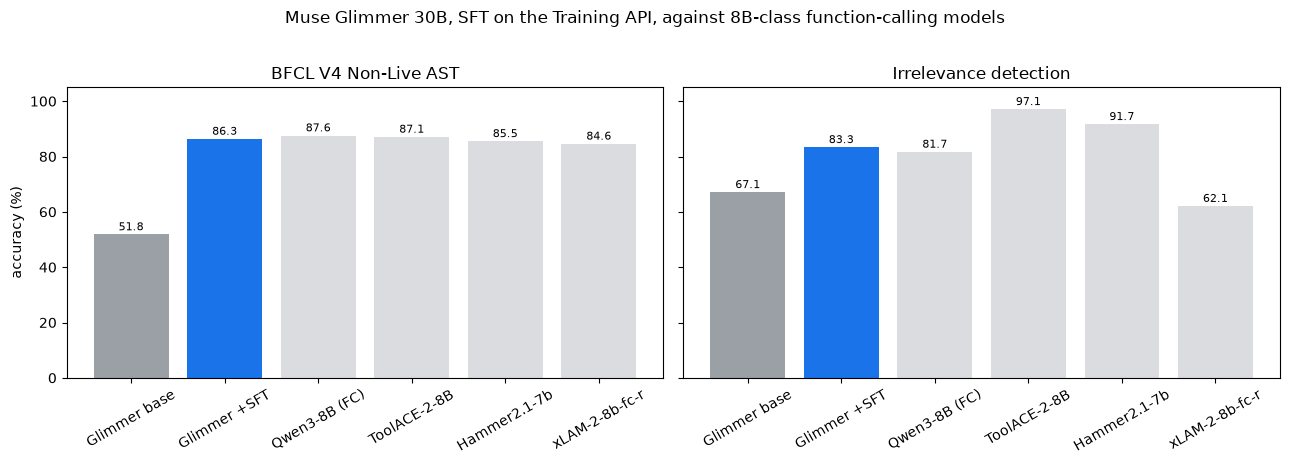

In [14]:
import matplotlib.pyplot as plt

# Published BFCL V4 non-live numbers (2025-12-16 snapshot), for context. These are 7-9B models
# specifically tuned for function calling; note how little the AST column moves across them.
BOARD = {
    "Qwen3-8B (FC)": (87.58, 81.67),
    "ToolACE-2-8B": (87.10, 97.08),
    "Hammer2.1-7b": (85.50, 91.67),
    "xLAM-2-8b-fc-r": (84.58, 62.08),
}
labels = ["Glimmer base", "Glimmer +SFT"] + list(BOARD)
ast = [base_summary["non_live_ast"], tuned_summary["non_live_ast"]] + [v[0] for v in BOARD.values()]
irr = [base_summary["irrelevance"], tuned_summary["irrelevance"]] + [v[1] for v in BOARD.values()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, vals, title in ((axes[0], ast, "BFCL V4 Non-Live AST"),
                        (axes[1], irr, "Irrelevance detection")):
    ax.bar(labels, vals, color=["#9aa0a6", "#1a73e8"] + ["#dadce0"] * len(BOARD))
    ax.set_title(title)
    ax.set_ylim(0, 105)
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(vals):
        ax.text(i, v + 1.5, f"{v:.1f}", ha="center", fontsize=8)
axes[0].set_ylabel("accuracy (%)")
fig.suptitle("Muse Glimmer 30B, SFT on the Training API, against 8B-class function-calling models",
             y=1.02)
fig.tight_layout()
plt.show()

In [15]:
from bfcl_score import attribute_gain

print(f"{'category':20s} {'emitted (base->tuned)':>24s} {'decision acc (both emitted)':>30s}")
print("-" * 78)
for cat in NON_LIVE_AST:
    g = attribute_gain(cat, EVAL[cat],
                       load_results(BFCL_PROJECT_ROOT, BASE_LABEL, cat),
                       load_results(BFCL_PROJECT_ROOT, OUTPUT_MODEL_ID, cat),
                       ANSWERS[cat])
    print(f"{cat:20s} {g['base_emitted']:>10d} -> {g['tuned_emitted']:<10d} "
          f"{g['base_decision_acc'] * 100:>13.1f}% -> {g['tuned_decision_acc'] * 100:<13.1f}%")
    print(f"{'':20s} {'':>24s} net {g['net_pp']:+.2f}pp "
          f"(emission {g['gain_emission'] - g['loss_emission']:+d} rows, "
          f"decision {g['gain_decision'] - g['loss_decision']:+d} rows)")

category                emitted (base->tuned)    decision acc (both emitted)
------------------------------------------------------------------------------
simple_python               398 -> 400                 88.9% -> 97.5         %
                                              net +8.75pp (emission +1 rows, decision +34 rows)
simple_java                  96 -> 100                 34.4% -> 39.6         %
                                              net +7.00pp (emission +2 rows, decision +5 rows)
simple_javascript            43 -> 50                  32.6% -> 39.5         %
                                              net +10.00pp (emission +2 rows, decision +3 rows)
multiple                    199 -> 200                 94.0% -> 97.0         %
                                              net +3.50pp (emission +1 rows, decision +6 rows)
parallel                    198 -> 200                 28.3% -> 96.0         %
                                              net +68.00pp (emissio

## 9. The same run on the other two paths

Nothing below executes — it is the *same* training run expressed three ways, so the differences are
concrete. §6 ran the first one.

### Dedicated: the same `Config`, plus the hardware

```python
dedicated_cfg = dataclasses.replace(
    cfg,
    serverless=False,                                   # provision a trainer for this job
    max_seq_len=None,                                   # resolved from the shape instead
    trainer=TrainerConfig(                              # the ONLY accelerator control
        training_shape_id="accounts/fireworks/trainingShapes/muse-glimmer-30b-131k-lora"),
)
```

Two fields and one addition. `training_shape_id` is the whole hardware decision —
`accelerator_type` and `accelerator_count` raise `TypeError` by design, because the shape already
fixes GPU count, context length, and trainer mode. You also inherit a trainer lifecycle: ~10 minutes
to provision, GPU-hours for as long as it is up, and teardown to get right (`sft_loop` sets
`cleanup_trainer_on_close=True`, and an idle trainer
[stops itself after 10 minutes](https://docs.fireworks.ai/fine-tuning/training-api/reference/cleanup#trainer-inactivity-cleanup)).

**Full-parameter is a property of the shape, not of the dedicated path.** Muse Glimmer publishes
`muse-glimmer-30b-131k-lora` (`LORA_TRAINER`, 1 × B200) *and* `muse-glimmer-30b-131k`
(`POLICY_TRAINER`, 2 × B200); with `lora_rank=0` you get the latter. Choosing dedicated grants
nothing by itself — the shape id decides. List yours with
`firectl training-shape list --no-paginate -o json`.

### Managed: no loop at all

```python
job = client.supervised_fine_tuning_jobs.create(
    dataset=dataset_name,          # upload the same JSONL first
    base_model=BASE_MODEL,
    output_model=f"accounts/{ACCOUNT_ID}/models/{OUTPUT_MODEL_ID}",
    epochs=EPOCHS, lora_rank=LORA_RANK, learning_rate=LEARNING_RATE,
    batch_size_samples=BATCH_SIZE, # the managed name for sft_loop's batch_size
    eval_auto_carveout=True,       # hold out 10% and report eval loss per epoch -- free here,
)                                  # and off by default in sft_loop
```

Same data, same hyperparameters, no `forward_backward`. You give up custom losses and any
step-level control; you gain per-job billing and one less thing to operate.

### Choosing

| | Serverless (§6) | Dedicated | Managed |
| --- | --- | --- | --- |
| Wait before step 1 | seconds | ~10 min provisioning | queued by Fireworks |
| Billing | per token, no idle GPU | GPU-hours while up | per job |
| Tuning mode | LoRA only | LoRA **or** full-parameter | LoRA (see §2) |
| Custom loss / reward | yes | yes | no |
| Models | the serverless pool | anything with a training shape | anything managed-enabled |

Reach for **dedicated** when you need full-parameter, a model outside the pool, or explicit control
of the hardware and checkpoint lifecycle. Reach for **managed** when a standard job does the work.
Otherwise serverless is the cheapest way to own a loop.

> **Model availability is per-path and can also be per-account.** Beyond the catalog's
> `hasServerless` / `managedSft` flags, an account can carry a model-access policy that allows some
> capabilities and not others for a specific model — in which case training fails with a 403 naming
> the policy, and an account admin has to change it. Check the
> [Models catalog](https://docs.fireworks.ai/fine-tuning/models) per model *and* per method, and do
> not assume a model that trains one way trains another.

## 10. Cleanup — tear down the deployments

Idle on-demand GPUs keep billing GPU-hours. Run this even if something above failed.

In [ ]:
def teardown(dep_id):
    try:
        # ignore_checks bypasses the recent-traffic guard, which otherwise blocks
        # deletion for about an hour after the last request.
        client.deployments.delete(dep_id, ignore_checks=True)
        print("deleted", dep_id)
    except Exception as exc:  # noqa: BLE001
        try:
            client.deployments.scale(dep_id, replica_count=0)
            print("scaled to 0 (delete failed:", str(exc)[:80], ")")
        except Exception as exc2:  # noqa: BLE001
            print("MANUAL CLEANUP NEEDED for", dep_id, "-", str(exc2)[:120])


for _d in dict.fromkeys(CREATED_DEPLOYMENTS):   # dedup, preserve order
    teardown(_d)

print("\nremaining deployments:")
for d in client.deployments.list():
    print(" ", d.name, getattr(d, "state", None))

## Recap

1. **`serverless=True` is the entire difference between the two infrastructures.** §8 was §6 with
   three fields changed. Underneath it is three calls — `render_messages_to_datums` locally, then
   `forward_backward(datums, "cross_entropy")` and `optim_step(AdamParams)` remotely. Two cheap
   mistakes: forgetting **`.result()`** (futures swallow failures) and treating **`loss:sum`** as a
   mean. Choose dedicated for full-parameter or a shape you control; serverless when the model is
   pooled and you would rather not hold a GPU.
2. **Verify that the knob you turned had the effect you wanted.** Reasoning controls are
   model-family-specific, and a request carrying the wrong one still succeeds — so the model reasons
   to its token cap and the truncated reply scores as a deliberate abstention. Asserting prompt
   parity does not catch this, because the assertion checks configuration rather than what the
   server did. **`finish_reason` is the evidence**, and §5 gates on it. Measurements in the README.
3. **Two metrics or none, and never let a failed measurement look like a bad model.** AST and
   irrelevance move in opposite directions under the same data knob. Worse, three different events
   — an API error, a truncation, and a genuine refusal — all produce an empty call list, which
   scores *wrong* on AST and *right* on irrelevance. `generation_failures` and `truncated_rows`
   tell them apart; accuracy never will.
4. **Pick the method from the failure mode.** Emission failures want demonstrations, and SFT fixes
   them. Decision failures — a well-formed call for the wrong function — want a reward over your own
   tools, and no amount of someone else's demonstrations moves them. SFT is still the right *first*
   stage when RL is the goal: an unparseable rollout scores zero regardless of its tool choice.

**Adapting this:** replace §4 and nothing else — everything downstream needs only JSONL rows of
`{"messages": [...], "tools": [...]}`. Then **measure your own base first.** The same abstention
data that lifts a model starting low can *cost* a model that is already well calibrated: nothing
left to teach, something to lose. One baseline sweep tells you which one you have.

### Related

[Training Overview](https://docs.fireworks.ai/fine-tuning/finetuning-intro) ·
[Managed](https://docs.fireworks.ai/fine-tuning/managed-finetuning-intro) ·
[Training API](https://docs.fireworks.ai/fine-tuning/training-api/introduction) ·
[Serverless](https://docs.fireworks.ai/fine-tuning/training-api/serverless) ·
[Dedicated](https://docs.fireworks.ai/fine-tuning/training-api/dedicated) ·
[SFT recipe](https://docs.fireworks.ai/fine-tuning/training-api/cookbook/sft) ·
[`sft_loop.py`](https://github.com/fw-ai/cookbook/blob/main/training/recipes/sft_loop.py) ·
[Models catalog](https://docs.fireworks.ai/fine-tuning/models) ·
[Training shapes](https://docs.fireworks.ai/fine-tuning/training-api/training-shapes) ·
[Evaluating fine-tunes](https://docs.fireworks.ai/fine-tuning/evaluating-fine-tuned-models) ·
[Deploying LoRAs](https://docs.fireworks.ai/fine-tuning/deploying-loras) ·
[Reasoning](https://docs.fireworks.ai/guides/reasoning)

Managed SFT examples:
[`sft_prompt_router`](https://github.com/fw-ai/cookbook/tree/main/training/case-studies/sft_prompt_router) ·
[`sft_cord_receipts`](https://github.com/fw-ai/cookbook/tree/main/training/case-studies/sft_cord_receipts) ·
RL: [`agentic_rl_text2sql`](https://github.com/fw-ai/cookbook/tree/main/training/case-studies/agentic_rl_text2sql)